## Entanglement swapping of partially entangled states in the light of Complementarity

Dado que os estados $$|\xi\rangle_{AB}=\sqrt{p}|00\rangle_{AB}+\sqrt{1-p}|11\rangle_{AB}$$ and $$|\eta\rangle_{CD}=\sqrt{q}|00\rangle_{CD}+\sqrt{1-q}|11\rangle_{CD}$$ são preparados. 

The quantons B and C are sent to Charlie, who makes a selective Bell basis measurement (BBM) on them. The quanton A is sent to Alice and the quanton D is sent to Bob. In the end of the protocol, A and D, that have never met before, can get entangled. Let's do the math for the states:
\begin{align}
|\xi\rangle_{AB}\otimes|\eta\rangle_{CD} &=  |\Phi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{pq}|00\rangle_{AD}+\sqrt{(1-p)(1-q)}|11\rangle_{AD}\big) +  |\Phi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{pq}|00\rangle_{AD}-\sqrt{(1-p)(1-q)}|11\rangle_{AD}\big) \\
& \hspace{0.5cm} + |\Psi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{p(1-q)}|01\rangle_{AD}+\sqrt{(1-p)q}|10\rangle_{AD}\big) + |\Psi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{p(1-q)}|01\rangle_{AD}-\sqrt{(1-p)q}|10\rangle_{AD}\big).
\end{align}

de modo que
\begin{align}
Pr(\Phi_{\pm}) = \frac{1}{2}(pq + (1-p)(1-q)), \ \ \  Pr(\Psi_{\pm}) = \frac{1}{2}(p(1-q) + (1-p)q).
\end{align}



In [2]:
import math

def E_Phi(p, q):
    a = p*q + (1-p)*(1-q)
    return -(p*q/a)*math.log2(p*q/a) -((1-p)*(1-q)/a)*math.log2((1-p)*(1-q)/a)
def E_Psi(p, q):
    b = p*(1-q) +(1-p)*q
    return -(p*(1-q)/b)*math.log2(p*(1-q)/b) -((1-p)*q/b)*math.log2((1-p)*q/b) 

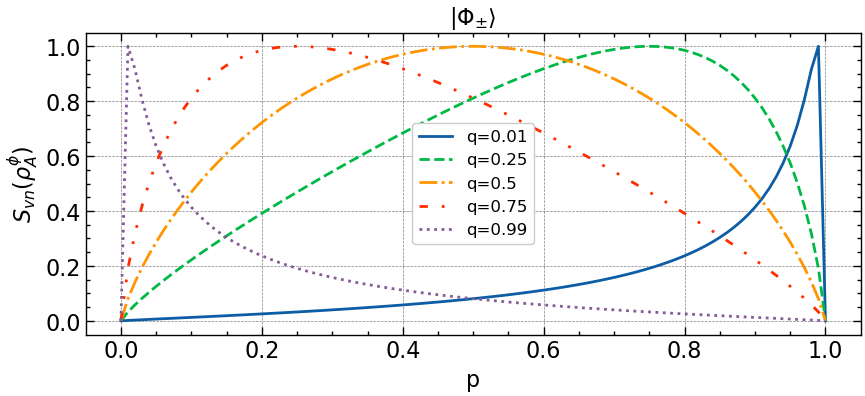

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (10,4), dpi = 100)

p = np.zeros(101)
Eq001 = np.zeros(101);  Eq025 = np.zeros(101); Eq05 = np.zeros(101)
Eq099 = np.zeros(101);  Eq075 = np.zeros(101)
for j in range(0, 101):
    p[j] = j*0.01
    if p[j] != 0 and p[j] != 1:
        q = 0.01; Eq001[j] = E_Phi(p[j], q)
        q = 0.25; Eq025[j] = E_Phi(p[j],q)
        q = 0.5; Eq05[j] = E_Phi(p[j],q); q = 0.75; Eq075[j] = E_Phi(p[j],q)
        q = 0.99; Eq099[j] = E_Phi(p[j],q)
plt.plot(p, Eq001, linestyle="-",); plt.plot(p, Eq025, linestyle="--",); plt.plot(p, Eq05, linestyle="-.",)
plt.plot(p, Eq075, linestyle=(0, (3, 5, 1, 5, 1, 5)),); plt.plot(p, Eq099, linestyle=":",)
plt.xlabel('p'); plt.ylabel(r'$S_{vn}(\rho^{\phi}_{A})$')
plt.legend(('q=0.01','q=0.25','q=0.5','q=0.75','q=0.99'),loc='best', fontsize = 12)
plt.title(r'$|\Phi_{\pm}\rangle$')
plt.savefig('entangs.pdf', format='pdf',dpi = 1200, bbox_inches='tight')
plt.show()



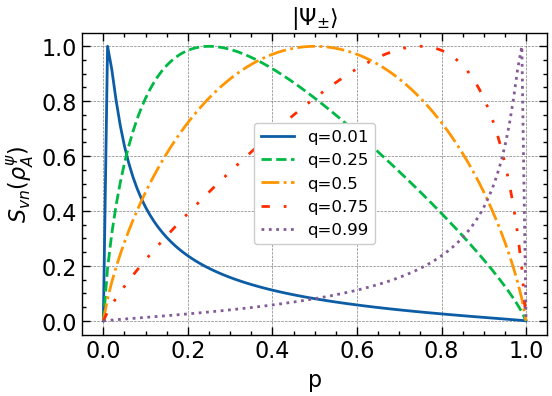

In [21]:
matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (6,4), dpi = 100)
plt.style.use(['science', 'notebook', 'grid'])    


p = np.zeros(101)
Eq001 = np.zeros(101); Eq025 = np.zeros(101); Eq05 = np.zeros(101)
Eq0 = np.zeros(101); Eq099 = np.zeros(101);  Eq075 = np.zeros(101)
for j in range(0, 101):
    p[j] = j*0.01
    if p[j] != 0 and p[j] != 1:
        q = 0.01; Eq001[j] = E_Psi(p[j], q)
        q = 0.25; Eq025[j] = E_Psi(p[j],q)
        q = 0.5; Eq05[j] = E_Psi(p[j],q); q = 0.75; Eq075[j] = E_Psi(p[j],q)
        q = 0.99; Eq099[j] = E_Psi(p[j],q)
plt.plot(p, Eq001, linestyle="-",); plt.plot(p, Eq025, linestyle="--",); plt.plot(p, Eq05, linestyle="-.",)
plt.plot(p, Eq075, linestyle=(0, (3, 5, 1, 5, 1, 5)),); plt.plot(p, Eq099, linestyle=":",)
plt.xlabel('p'); plt.ylabel(r'$S_{vn}(\rho^{\psi}_{A})$')
plt.legend(('q=0.01','q=0.25','q=0.5','q=0.75','q=0.99'),loc='best', fontsize = 12)
plt.title(r'$|\Psi_{\pm}\rangle$')
plt.savefig('entangss.pdf', format='pdf',dpi = 1200, bbox_inches='tight')
plt.show()



In [2]:
import math
import sympy as sym
from sympy import *

p = symbols('p'); 
q = symbols('q');

def E_Phi(p, q):
    return -(p*q/(p*q + (1-p)*(1-q)))*sym.log(p*q/(p*q + (1-p)*(1-q))) -((1-p)*(1-q)/(p*q + (1-p)*(1-q)))*sym.log((1-p)*(1-q)/(p*q + (1-p)*(1-q)))
def E_Psi(p, q):
    return -(p*(1-q)/(p*(1-q) +(1-p)*q))*sym.log(p*(1-q)/(p*(1-q) +(1-p)*q)) -((1-p)*q/(p*(1-q) +(1-p)*q))*sym.log((1-p)*q/(p*(1-q) +(1-p)*q)) 

In [3]:
E_Phi(p, q)

-p*q*log(p*q/(p*q + (1 - p)*(1 - q)))/(p*q + (1 - p)*(1 - q)) - (1 - p)*(1 - q)*log((1 - p)*(1 - q)/(p*q + (1 - p)*(1 - q)))/(p*q + (1 - p)*(1 - q))

In [4]:
from sympy import *

A = factor(diff(E_Phi(p,q),p))

simplify(A)

q*(q - 1)*(-log((p*q - p - q + 1)/(2*p*q - p - q + 1)) + log(p*q/(2*p*q - p - q + 1)))/(2*p*q - p - q + 1)**2

In [31]:
from sympy import *

B = factor(diff(E_Psi(p,q),p))

simplify(B)

q*(q - 1)*(log(p*(1 - q)/(-2*p*q + p + q)) - log(q*(1 - p)/(-2*p*q + p + q)))/(-2*p*q + p + q)**2

Pelas, expressões acima, podemos ver que
\begin{align}
& \frac{d}{dp}E(\rho^{\Phi}_{AD}) = 0 \iff p = 1 - q, \\
& \frac{d}{dp}E(\rho^{\Psi}_{AD}) = 0 \iff p = q.
\end{align}

Assim, podemos ver que dado um valor $q$, sempre existe um $p$ tal que $E(\rho_{AD})$ é máximo.

#### Escolha: $p = 1 - q$

\begin{align}
|\xi\rangle_{AB}\otimes|\eta\rangle_{CD} & = \sqrt{(1-q)q}|\Phi_{+}\rangle_{BC}|\Phi_{+}\rangle_{AD} + \sqrt{(1-q)q}|\Phi_{-}\rangle_{BC}|\Phi_{-}\rangle_{AD} \\
& \hspace{0.5cm} + |\Psi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{(1-q)^{2}}|01\rangle_{AD}+\sqrt{q^{2}}|10\rangle_{AD}\big) + |\Psi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{(1-q)^{2}}|01\rangle_{AD}-\sqrt{q^{2}}|10\rangle_{AD}\big)
\end{align}

#### Escolha: $p=q$
\begin{align}
|\xi\rangle_{AB}\otimes|\eta\rangle_{CD} 
&= |\Phi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{q^{2}}|00\rangle_{AD}+\sqrt{(1-q)^{2}}|11\rangle_{AD}\big) +  |\Phi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{q^{2}}|00\rangle_{AD}-\sqrt{(1-q)^{2}}|11\rangle_{AD}\big) \\
& \hspace{0.5cm} + \frac{\sqrt{q(1-q)}}{\sqrt{2}}|\Psi_{+}\rangle_{BC}|\Psi_{+}\rangle_{AD} + \frac{\sqrt{q(1-q)}}{\sqrt{2}}|\Psi_{-}\rangle_{BC}|\Psi_{-}\rangle_{AD}
\end{align}

Assim, podemos que, se escolhemos $q = 0.99$, então

#### $p = 1-q$:
\begin{align}
Pr(\Psi_{\pm}) >> Pr(\Phi_{\pm}),  
\end{align}
uma vez que
\begin{align}
Pr(\Psi_{\pm}) = \frac{1}{2}((1 - q)^2 +  q^2) = 0.4901, \ \ \ Pr(\Phi_{\pm}) = (1-q)q = 0.0099   
\end{align}
####  $p = q$:
\begin{align}
Pr(\Phi_{\pm}) >> Pr(\Psi_{\pm}).  
\end{align}


Ou seja, escolhendo $q = 0.99$, basta escolher $p = 1-q$ que obteremos os estados $|\Psi_{\pm}\rangle$ na grande maioria das vezes. 

Se escolhemos $q = 0.75$, então

#### $p = 1-q$:
\begin{align}
Pr(\Psi_{\pm}) >> Pr(\Phi_{\pm}),  
\end{align}
uma vez que
\begin{align}
Pr(\Psi_{\pm}) = \frac{1}{2}((1 - q)^2 +  q^2) = 0.3125, \ \ \ Pr(\Phi_{\pm}) = (1-q)q = 0.1875   
\end{align}
####  $p = q$:
\begin{align}
Pr(\Phi_{\pm}) >> Pr(\Psi_{\pm}).  
\end{align}




#### O papel da Complementariedade

É curioso o fato de que é possível começar com dois pares de estados minimamente emaranhados e acabar com dois estados maximamente emaranhados em algumas poucas vezes. Parece que o emaranhamento foi gerado do nada. Mas uma explicação possível é que o emaranhamento foi catalisado através da complementariedade. Para isso, notemos que, inicialmente, dado os estados
$$|\xi\rangle_{AB}=\sqrt{p}|00\rangle_{AB}+\sqrt{1-p}|11\rangle_{AB}$$ and $$|\eta\rangle_{CD}=\sqrt{q}|00\rangle_{CD}+\sqrt{1-q}|11\rangle_{CD}$$
temos que
\begin{align}
P_{vn}(\rho_j) \neq 0 \ \ \ \, S_{vn}(\rho_j) \neq 0, j = A,B,C,D,
\end{align}
ou seja, temos tanto predibilidade dos qubits locais, quanto emaranhamento entre $AB$ e $CD$, tal que
\begin{align}
P_{vn}(\rho_j) + S_{vn}(\rho_j) = 1.
\end{align}
E, ao final, obtemos
\begin{align}
P_{vn}(\rho_j) = 0 \ \ \  S_{vn}(\rho_j) = 1, \ \ \ \forall j = A,B,C,D.
\end{align}
Isso significa que a predibilidade foi consumida (ou serviu como catalisador) para termos no final dois pares maximamente emaranhados. Essa preditibilidade local e inicial alta mais tarde irá refletir o fato de que, dado $q = 0.99$, e escolhermos $p = 1-q$, sabemos que, depois das medidas na base de Bell, obteremos os estados $|\Psi_{\pm}\rangle$ com grande probabilidade, ou seja, nossa capacidade de prever tal resultado é alta, uma vez que 
\begin{align}
\rho_{BC} = (1-q)q(|\Phi_+\rangle\langle\Phi_+| + |\Phi_-\rangle\langle\Phi_-|) + \frac{1}{2}((1 - q)^2 + q^2)(|\Psi_+\rangle\langle\Psi_+| + |\Psi_-\rangle\langle\Psi_-|).
\end{align}

Se fizemos a seguinte identificação
\begin{align}
& |\Phi_+\rangle\langle\Phi_+| + |\Phi_-\rangle\langle\Phi_-| \to 2|0\rangle\langle0|, \\
& |\Psi_+\rangle\langle\Psi_+| + |\Psi_-\rangle\langle\Psi_-| \to 2|1\rangle\langle1|,
\end{align}
uma vez que estamos interessado no ensemble $\Phi_{\pm}$ ou $\Psi_{\pm}$ então
temos que
\begin{align}
\rho = 2(1-q)q|0\rangle\langle0| + ((1 - q)^2 + q^2)|1\rangle\langle1|.
\end{align}


Uma outra maneira de ver isso é a seguinte:
\begin{align}
Pr(\Psi_{\pm}) = \frac{1}{2}(q^2 + (1 -q)^2) = \frac{1}{2}(P_l(\rho^i_A) + 1/2)).
\end{align}
Ou ainda, dado que
\begin{align}
P_{vn}(\rho^i_A) = \log 2 + q \log q + (1-q)\log(1-q) = q^2 + (1-q)^2 + (1 - 1/\ln 2) + \mathcal{O}(q^3),
\end{align}
e, portanto,
\begin{align}
P_{vn}(\rho^i_A) = Pr(\Psi_+) + Pr(\Psi_-) - 0.44  + \mathcal{O}(q^3).
\end{align}

In [40]:
import math

def P_Psi(q):
    return math.log2(4) + 2*(1-q)*q*math.log2((1-q)*q) + (1 - 2*q + 2*q**2)*math.log2(0.5*(1 - 2*q + 2*q**2))
def Pcod_Psi(q):
    return math.log2(2) + 2*(1-q)*q*math.log2(2*(1-q)*q) + (1 - 2*q + 2*q**2)*math.log2((1 - 2*q + 2*q**2))
def Ploc_Psi(q):
    return math.log2(2) + q*math.log2(q) + (1-q)*math.log2(1-q)

In [36]:
P_Psi(0.99)

0.8596838763959702

In [38]:
Pcod_Psi(0.99)

0.85968387639597

In [41]:
Ploc_Psi(0.99)

0.9192068641040887

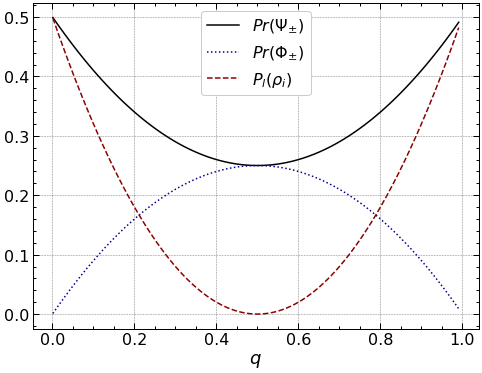

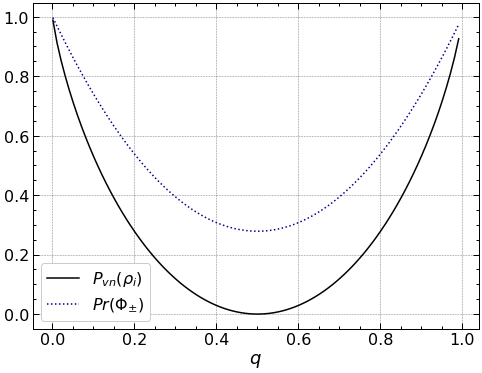

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

x = np.arange(0.001, 1, 0.01)

f = 0.5*(1 -2*x +2*x**2)
g = x*(1 - x)
p = x**2 + (1 -x)**2 - 1/2
h = 0.5*(x*np.log2(x) + (1-x)*np.log2(1-x) + 1)
m = (x*np.log2(x) + (1-x)*np.log2(1-x) + 1)
n = (x**2 + (1 -x)**2)/np.log(2) + (1 - 1/np.log(2))
plt.plot(x, f, color="black", linewidth=1.5, linestyle="-", label= r'$Pr(\Psi_{\pm})$')
plt.plot(x, g, color="darkblue", linewidth=1.5, linestyle=":", label= r'$Pr(\Phi_{\pm})$')
plt.plot(x, p, color="darkred", linewidth=1.5, linestyle="--", label= r'$P_{l}(\rho_i)$')
#plt.plot(x, h, color="darkgreen", linewidth=1.5, linestyle="-.", label= r'$P_{vn}(\rho_i)$')

plt.xlabel(r'$q$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.savefig('prpl.pdf', format='pdf',dpi = 1200, bbox_inches='tight')
plt.show()


plt.plot(x, m, color="black", linewidth=1.5, linestyle="-", label= r'$P_{vn}(\rho_i)$')
plt.plot(x, n, color="darkblue", linewidth=1.5, linestyle=":", label= r'$Pr(\Phi_{\pm})$')

plt.xlabel(r'$q$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.show()


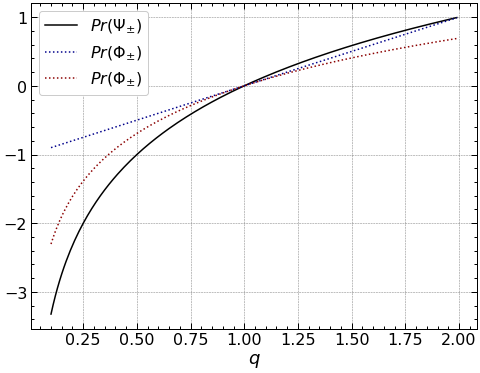

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

x = np.arange(0.1, 2, 0.01)

f = np.log2(x)
g = x - 1
h = np.log(x)
plt.plot(x, f, color="black", linewidth=1.5, linestyle="-", label= r'$Pr(\Psi_{\pm})$')
plt.plot(x, g, color="darkblue", linewidth=1.5, linestyle=":", label= r'$Pr(\Phi_{\pm})$')
plt.plot(x, h, color="darkred", linewidth=1.5, linestyle=":", label= r'$Pr(\Phi_{\pm})$')


plt.xlabel(r'$q$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)


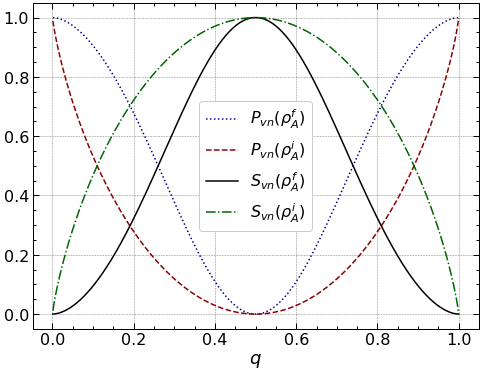

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

x = np.arange(0.001, 1, 0.0001)

a = (1 - x)**2 + x**2
f = 1 + ((1-x)**2/a)*np.log2((1-x)**2/a) + ((x)**2/a)*np.log2((x)**2/a)
h = x*np.log2(x) + (1-x)*np.log2(1-x) + 1
g = 1 - f
m = 1 - h

plt.plot(x, f, color="darkblue", linewidth=1.5, linestyle=":", label= r'$P_{vn}(\rho^f_A)$')
plt.plot(x, h, color="darkred", linewidth=1.5, linestyle="--", label= r'$P_{vn}(\rho^i_A)$')
plt.plot(x, g, color="black", linewidth=1.5, linestyle="-", label= r'$S_{vn}(\rho^f_A)$')
plt.plot(x, m, color="darkgreen", linewidth=1.5, linestyle="-.", label= r'$S_{vn}(\rho^i_A)$')


plt.xlabel(r'$q$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.savefig('pvnif.pdf', format='pdf',dpi = 1200, bbox_inches='tight')
plt.show()

In [63]:
import math

def E_Phi(p, q):
    a = p*q + (1-p)*(1-q)
    return -(p*q/a)*math.log2(p*q/a) -((1-p)*(1-q)/a)*math.log2((1-p)*(1-q)/a)
def E_Psi(p, q):
    b = p*(1-q) +(1-p)*q
    return -(p*(1-q)/b)*math.log2(p*(1-q)/b) -((1-p)*q/b)*math.log2((1-p)*q/b) 

def S_Phi(p):
    return -(p)*math.log2(p) -(1-p)*math.log2(1-p)
def S_Psi(q):
    return -(q)*math.log2(q) -(1-q)*math.log2(1-q)

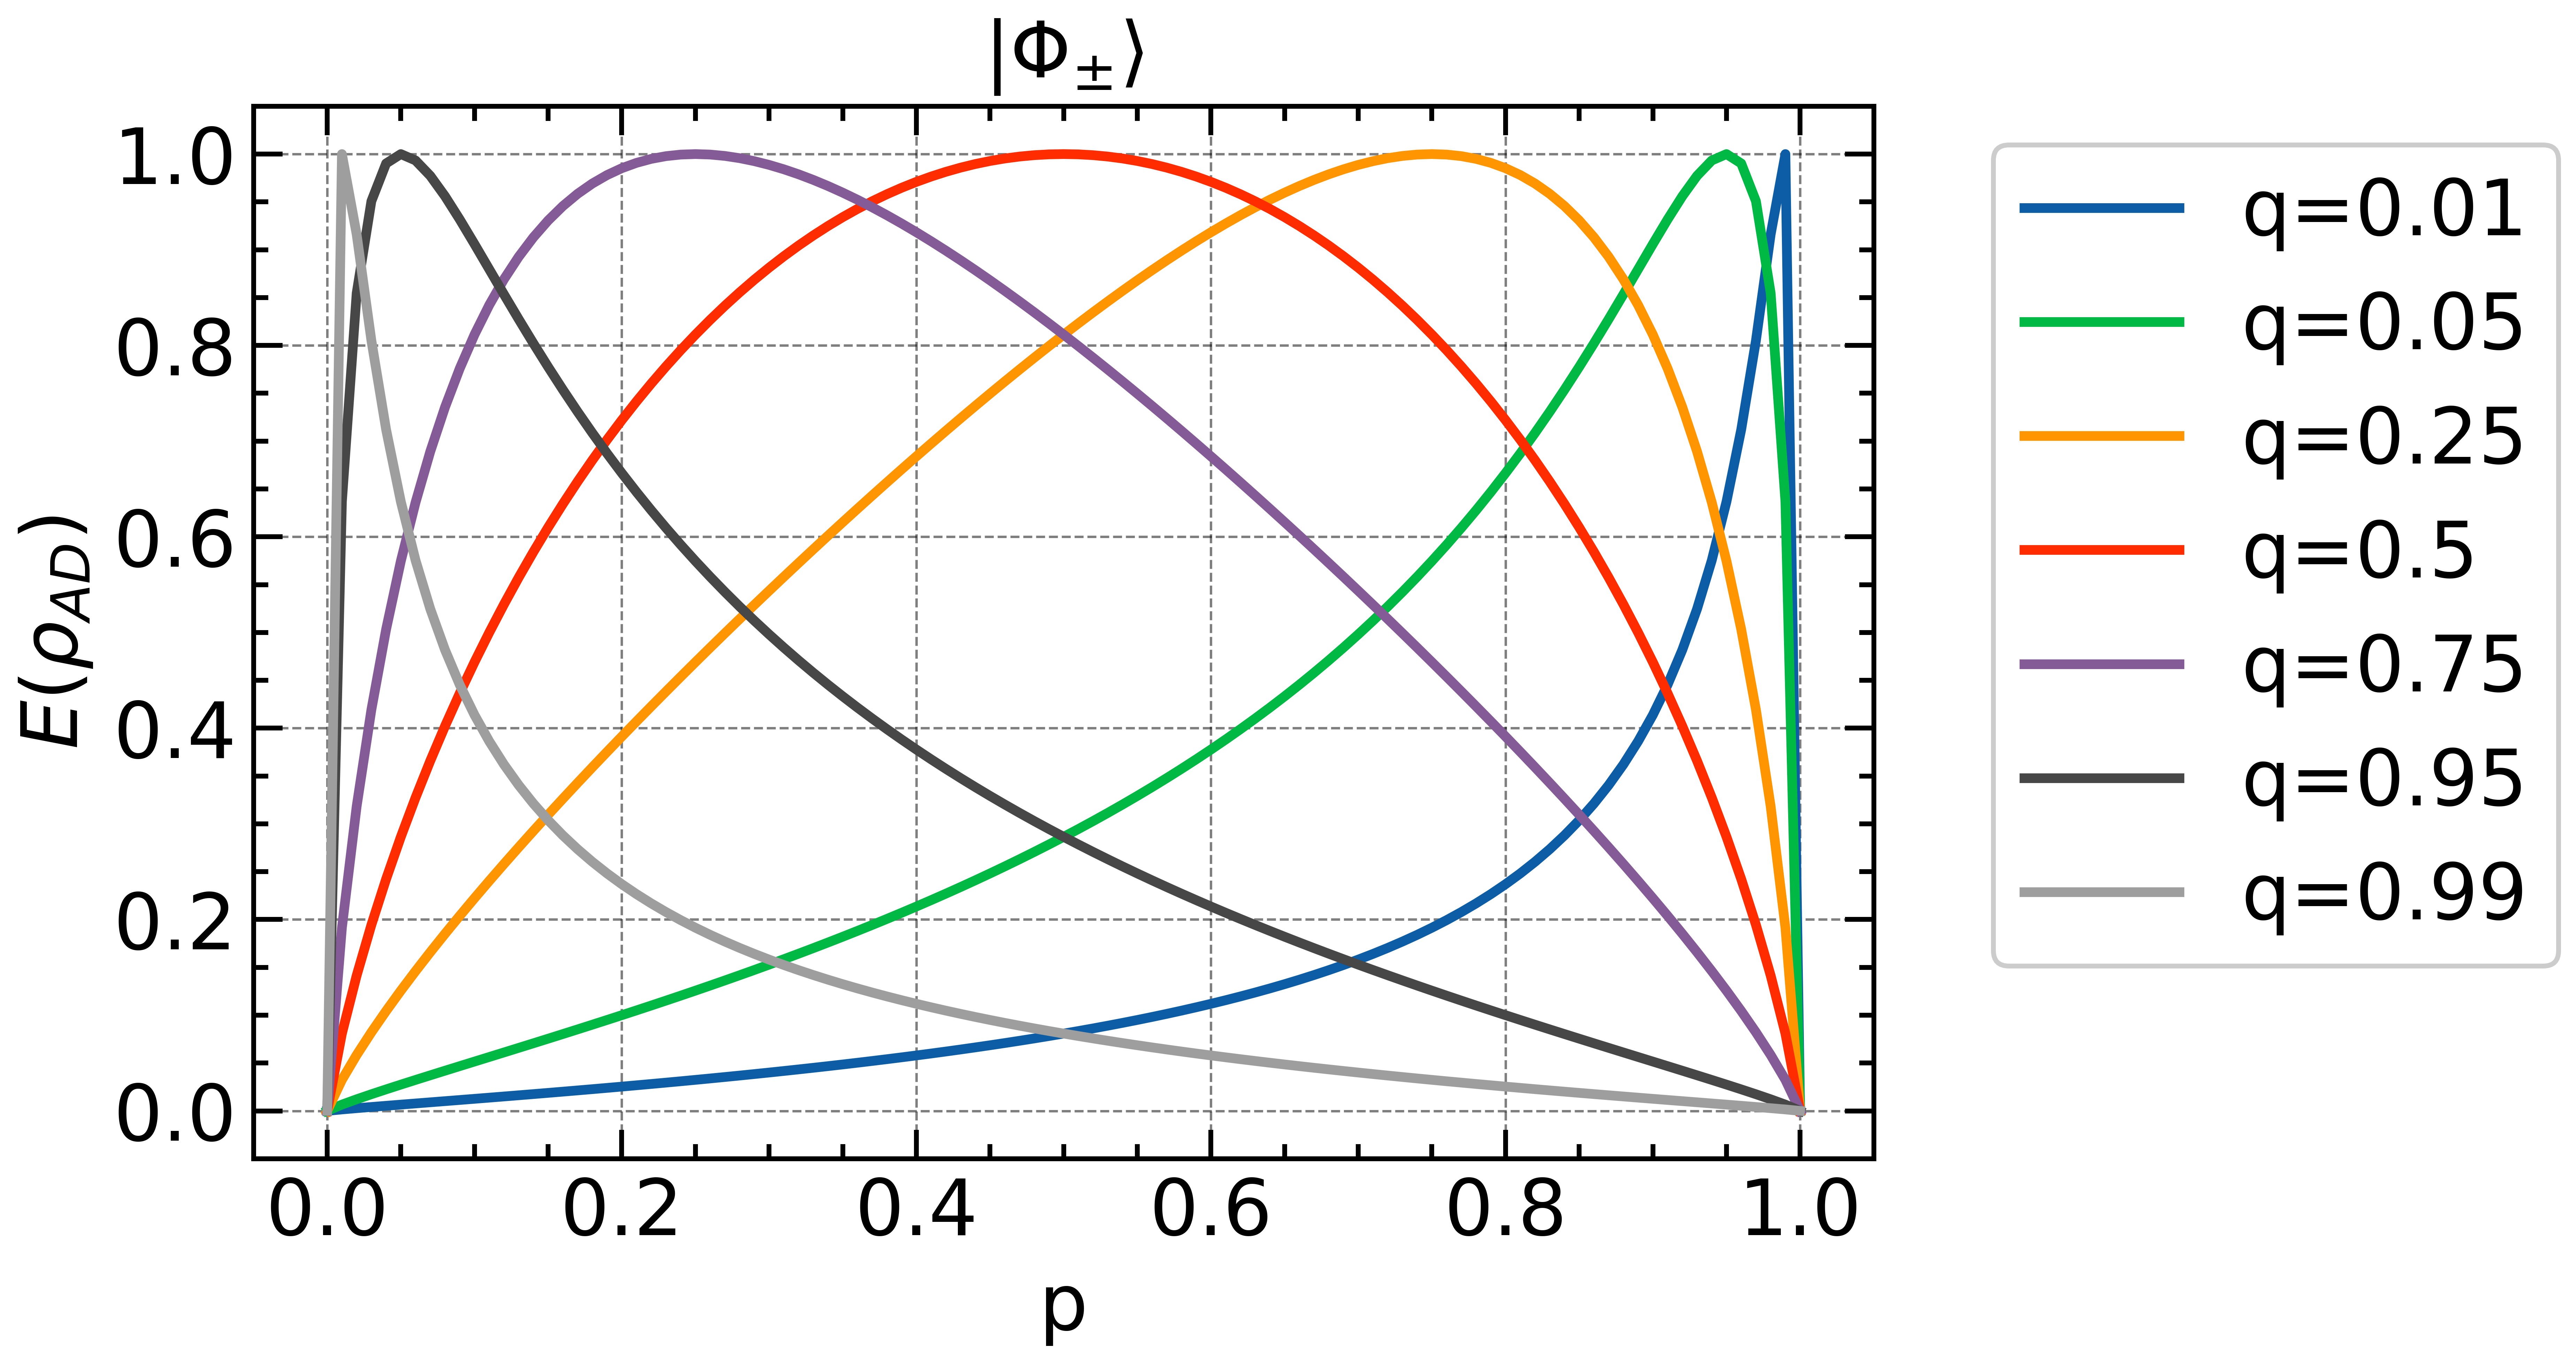

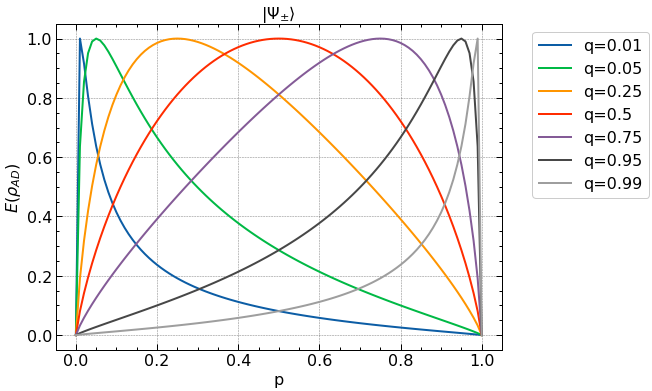

In [52]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (6,4), dpi = 1000)

p = np.zeros(101)
Eq001 = np.zeros(101); Eq005 = np.zeros(101); Eq025 = np.zeros(101); Eq05 = np.zeros(101)
Eq099 = np.zeros(101); Eq095 = np.zeros(101); Eq075 = np.zeros(101)
for j in range(0, 101):
    p[j] = j*0.01
    if p[j] != 0 and p[j] != 1:
        q = 0.01; Eq001[j] = E_Phi(p[j], q)
        q = 0.05; Eq005[j] = E_Phi(p[j], q); q = 0.25; Eq025[j] = E_Phi(p[j],q)
        q = 0.5; Eq05[j] = E_Phi(p[j],q); q = 0.75; Eq075[j] = E_Phi(p[j],q)
        q = 0.95; Eq095[j] = E_Phi(p[j],q); q = 0.99; Eq099[j] = E_Phi(p[j],q)
plt.plot(p, Eq001); plt.plot(p, Eq005); plt.plot(p, Eq025); plt.plot(p, Eq05)
plt.plot(p, Eq075); plt.plot(p, Eq095); plt.plot(p, Eq099)
plt.xlabel('p'); plt.ylabel(r'$E(\rho_{AD})$')
plt.legend(('q=0.01','q=0.05','q=0.25','q=0.5','q=0.75','q=0.95','q=0.99'), 
           bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.title(r'$|\Phi_{\pm}\rangle$')
plt.show()




p = np.zeros(101)
Eq001 = np.zeros(101); Eq005 = np.zeros(101); Eq025 = np.zeros(101); Eq05 = np.zeros(101)
Eq0 = np.zeros(101); Eq099 = np.zeros(101); Eq095 = np.zeros(101); Eq075 = np.zeros(101)
for j in range(0, 101):
    p[j] = j*0.01
    if p[j] != 0 and p[j] != 1:
        q = 0.01; Eq001[j] = E_Psi(p[j], q)
        q = 0.05; Eq005[j] = E_Psi(p[j], q); q = 0.25; Eq025[j] = E_Psi(p[j],q)
        q = 0.5; Eq05[j] = E_Psi(p[j],q); q = 0.75; Eq075[j] = E_Psi(p[j],q)
        q = 0.95; Eq095[j] = E_Psi(p[j],q); q = 0.99; Eq099[j] = E_Psi(p[j],q)
plt.plot(p, Eq001); plt.plot(p, Eq005); plt.plot(p, Eq025); plt.plot(p, Eq05)
plt.plot(p, Eq075); plt.plot(p, Eq095); plt.plot(p, Eq099)
plt.xlabel('p'); plt.ylabel(r'$E(\rho_{AD})$')
plt.legend(('q=0.01','q=0.05','q=0.25','q=0.5','q=0.75','q=0.95','q=0.99'), 
           bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.title(r'$|\Psi_{\pm}\rangle$')
plt.show()


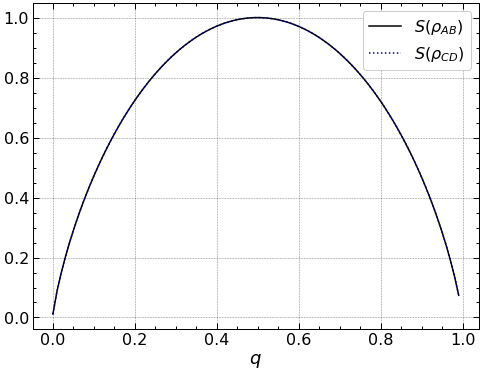

In [62]:
import numpy as np

p = np.arange(0.001, 1, 0.01)
q = np.arange(0.001, 1, 0.01)
f = -(p)*np.log2(p) -(1-p)*np.log2(1-p)
g = -(q)*np.log2(q) -(1-q)*np.log2(1-q)

plt.plot(x, f, color="black", linewidth=1.5, linestyle="-", label= r'$S(\rho_{AB})$')
plt.plot(x, g, color="darkblue", linewidth=1.5, linestyle=":", label= r'$S(\rho_{CD})$')


plt.xlabel(r'$q$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.show()

In [54]:
E_Phi(0.1, 0.75)


0.8112781244591329

In [55]:
E_Psi(0.1, 0.75)

0.22228483068568797

In [65]:
S_Phi(0.1)

0.4689955935892812

In [66]:
S_Psi(0.75)

0.8112781244591328

In [60]:
E_Phi(0.4, 0.8)


0.8453509366224363

In [61]:
E_Psi(0.4, 0.8)


0.5916727785823273

Na curva acima, consideremos $q = 0.75$ e $p =0.1$ de modo que $S(\rho_{AD}) \simeq 0.81$. E lembrando que
\begin{align}
|\xi\rangle_{AB}\otimes|\eta\rangle_{CD} &= |\Phi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{pq}|00\rangle_{AD}+\sqrt{(1-p)(1-q)}|11\rangle_{AD}\big) +  |\Phi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{pq}|00\rangle_{AD}-\sqrt{(1-p)(1-q)}|11\rangle_{AD}\big) \\
& \hspace{0.5cm} + |\Psi_{+}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{p(1-q)}|01\rangle_{AD}+\sqrt{(1-p)q}|10\rangle_{AD}\big) + |\Psi_{-}\rangle_{BC}\frac{1}{\sqrt{2}}\big(\sqrt{p(1-q)}|01\rangle_{AD}-\sqrt{(1-p)q}|10\rangle_{AD}\big).
\end{align}

Nesse caso, temos
\begin{align}
Pr(|\Phi_{\pm}\rangle = \frac{1}{2}(pq + (1-p)(1-q)) = 0.15, \ \ \ Pr(|\Psi{\pm}\rangle) = \frac{1}{2}(p(1-q) + (1-p)q) = 0.35.
\end{align}

Se obtermos $|Phi_{\pm}\rangle$, então temos que
\begin{align}
|\Phi_{\pm}\rangle_{BC} \ \Rightarrow \ |\hat{\phi}_{\pm}\rangle_{AD} = \frac{\big(\sqrt{pq}|00\rangle_{AD}\pm\sqrt{(1-p)(1-q)}|11\rangle_{AD}\big)}{\sqrt{pq+(1-p)(1-q)}},
\end{align}
sendo o estado que corresponde à $S(\rho_{AD}) \simeq 0.81$. Isso acontecerá com a taxa de $0.3$. 

Enquanto que se obtermos $|\Phi_{\pm}\rangle$, então
\begin{align}
|\Psi_{\pm}\rangle_{BC} \ \Rightarrow \ |\hat{\psi}_{\pm}\rangle_{AD} = \frac{\big(\sqrt{p(1-q)}|01\rangle_{AD}\pm\sqrt{(1-p)q}|10\rangle_{AD}\big)}{\sqrt{p(1-q)+(1-p)q}}. 
\end{align}
de modo que
\begin{align}
\rho_A = \frac{1}{p(1-q)+(1-p)q}\Big(p(1-q)|0\rangle \langle 0| + (1-p)q |1\rangle \langle 1| \Big)
\end{align}
que corresponde a estado misto, e portanto, $AD$ estão emaranhados, com  $S(\rho_{AD}) \simeq 0.22$

Os estados iniciais tinham emaramanhamento dado por
\begin{align}
& S(\rho_{AB}) = p\log_2 p + (1-p)\log_2(1-p), \\
& S(\rho_{CD}) = q\log_2 q + (1-q)\log_2(1-q)
\end{align}

In [56]:
E_Phi(0.25, 0.75)

1.0

In [57]:
E_Psi(0.25, 0.75)

0.4689955935892812

In [67]:
S_Phi(0.25)

0.8112781244591328

In [68]:
S_Psi(0.75)

0.8112781244591328

In [58]:
E_Phi(0.01, 0.99)

1.0

In [59]:
E_Psi(0.01, 0.99)

0.0014998451211920773

In [69]:
S_Phi(0.01)

0.08079313589591118

### Superdense Coding with Partially Entangled States

Consideremos o seguinte estado parcialmente emaranhado:
 $$|\Xi\rangle_{AB}=\sqrt{p}|00\rangle_{AB}+\sqrt{1-p}|11\rangle_{AB}.$$
 
Supondo que Alice manipula o qubit $A$ através das seguintes operações locais: $I \otimes I$ ou $Z \otimes I$ temos que
 $$|\Xi_{\pm}\rangle_{AB}=\sqrt{p}|00\rangle_{AB} \pm \sqrt{1-p}|11\rangle_{AB},$$
que ainda pode ser reescrito como
\begin{align}
|\Xi_{\pm}\rangle_{AB} = \frac{1}{\sqrt{2}}\Big(\sqrt{p} \pm \sqrt{1 - p}\Big)|\Phi_+\rangle_{AB} + \frac{1}{\sqrt{2}}\Big(\sqrt{p} \mp \sqrt{1 - p}\Big)|\Phi_-\rangle_{AB}.
\end{align}
Os estados locais são dados por
$$
\rho^i_A = \rho^i_B = p |0\rangle \langle 0| + (1-p) |1\rangle \langle 1|.
$$
Agora, consideremos que Alice deseja enviar a informação $00$ que está codificada no estado $|\Phi_+\rangle_{AB}$. Então depois da operação local realizada acima, Alice envia o seu qubit para Bob e então Bob faz uma medida na base Bell obtendo o estado $|\Phi_+\rangle_{AB}$ com a seguinte probabilidade:
\begin{align}
Pr(\Phi_+|\Xi_{\pm}) = \frac{1}{2}(\sqrt{p} \pm \sqrt{1 - p})^2 = \frac{1}{2} \pm \sqrt{p(1-p)}.
\end{align}
Bob também obterá invariavelmente o estado $|\Phi_-\rangle_{AB}$ com probabilidade 
\begin{align}
Pr(\Phi_-|\Xi_{\pm}) = \frac{1}{2}(\sqrt{p} \mp \sqrt{1 - p})^2 = \frac{1}{2} \mp \sqrt{p(1-p)}.
\end{align}

Vamos supor, sem perda de generalidade, que Alice envia o estado $|\Xi_{+}\rangle_{AB} $. Levando em conta a relação de complementariedade:
\begin{align}
P_l(\rho_A) + C_{hs}(\rho_A) + S_l(\rho_A) = 1/2,
\end{align}
e notemos que $C_{hs}(\rho^i_A) = 0$ onde $\rho^i_A =  Tr_B(|\Xi\rangle_{AB}\langle \Xi |)$. Assim, a preditibilidade do qubit $A$ será 
\begin{align}
P_l(\rho_A) = p^2 + (1-p)^2 - 1/2 = 1/2 - 2p(1-p),
\end{align}
que pode ser relacionada com as probabilidades de Bob obter os estados $\Phi_{\pm}$ após realizar a medida na base de Bell:
\begin{align}
Pr(\Phi_{\pm}|\Xi_{+}) = \frac{1}{2} \pm \sqrt{\frac{1}{2}\Big(\frac{1}{2} - P_l(\rho_A^i)\Big)}.
\end{align}

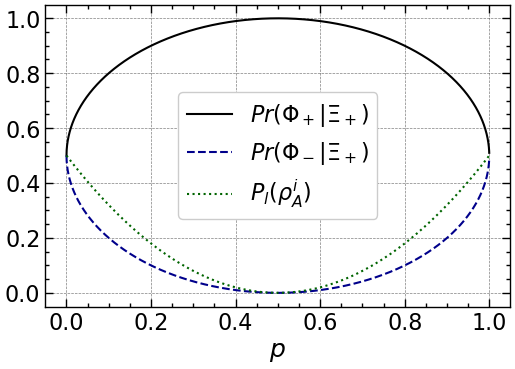

In [11]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    
matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (6,4), dpi = 100)
plt.style.use(['science', 'notebook', 'grid'])    


p = np.arange(0, 1, 0.0001)
f = 0.5 + np.sqrt(p*(1-p))
g = 0.5 - np.sqrt(p*(1-p))
P = 0.5 - 2*p*(1-p)
#p**2 + (1 - p)**2 - 1/2

plt.plot(p, f, color="black", linewidth=1.5, linestyle="-", label= r'$Pr(\Phi_+|\Xi_+)$')
plt.plot(p, g, color="darkblue", linewidth=1.5, linestyle="--", label= r'$Pr(\Phi_-|\Xi_+)$')
plt.plot(p, P, color="darkgreen", linewidth=1.5, linestyle=":", label= r'$P_l(\rho_A^i)$')


plt.xlabel(r'$p$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.show()


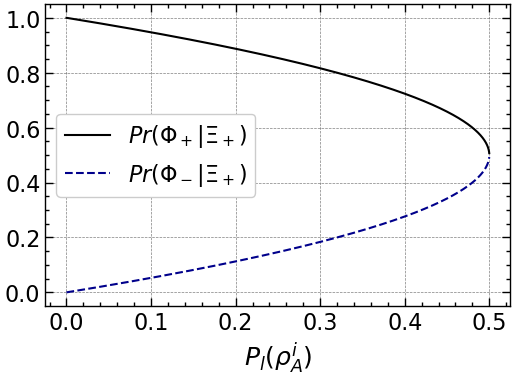

In [13]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    
matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (6,4), dpi = 100)
plt.style.use(['science', 'notebook', 'grid'])    


p = np.arange(0, 1/2, 0.0001)
f = 0.5 + np.sqrt(0.5*(0.5 - p))
g = 0.5 - np.sqrt(0.5*(0.5 - p))

#p**2 + (1 - p)**2 - 1/2

plt.plot(p, f, color="black", linewidth=1.5, linestyle="-", label= r'$Pr(\Phi_+|\Xi_+)$')
plt.plot(p, g, color="darkblue", linewidth=1.5, linestyle="--", label= r'$Pr(\Phi_-|\Xi_+)$')


plt.xlabel(r'$P_l(\rho_A^i)$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.show()


Agora, onsideremos o seguinte estado parcialmente emaranhado:
 $$|\Upsilon\rangle_{AB}=\sqrt{p}|+0\rangle_{AB}+\sqrt{1-p}|11\rangle_{AB}.$$
 
Supondo que Alice manipula o qubit $A$ através das seguintes operações locais: $I \otimes I$ ou $Z \otimes I$ temos que
 $$|\Upsilon_{\pm}\rangle_{AB}=\sqrt{p}|+0\rangle_{AB} \pm \sqrt{1-p}|11\rangle_{AB},$$
que ainda pode ser reescrito como
\begin{align}
|\Upsilon_{\pm}\rangle_{AB} = \frac{1}{\sqrt{2}}\Big(\sqrt{p/2} \pm \sqrt{1 - p}\Big)|\Phi_+\rangle_{AB} + \frac{1}{\sqrt{2}}\Big(\sqrt{p/2} \mp \sqrt{1 - p}\Big)|\Phi_-\rangle_{AB} + \frac{1}{\sqrt{2}}\sqrt{p/2}(|\Psi_+\rangle_{AB} - |\Psi_+\rangle_{AB}).
\end{align}

Agora, consideremos que Alice deseja enviar a informação $00$ que está codificada no estado $|\Phi_+\rangle_{AB}$. Então depois da operação local realizada acima, Alice envia o seu qubit para Bob e então Bob faz uma medida na base Bell obtendo o estado $|\Phi_+\rangle_{AB}$ com a seguinte probabilidade:
\begin{align}
Pr(\Phi_+|\Upsilon_{\pm}) = \frac{1}{2}(\sqrt{p/2} \pm \sqrt{1 - p})^2 = \frac{1}{2}(1 - p/2 \pm \sqrt{2p(1-p)}).
\end{align}




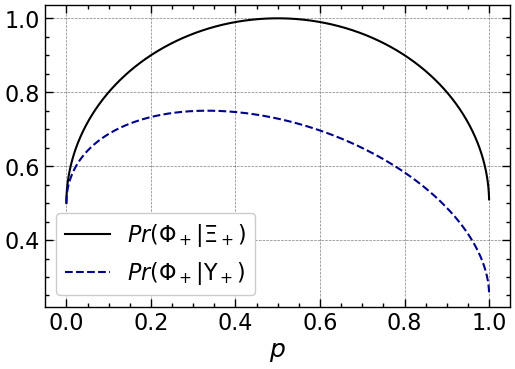

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    
matplotlib.rcParams.update({'font.size':12})
plt.figure(figsize = (6,4), dpi = 100)
plt.style.use(['science', 'notebook', 'grid'])    


p = np.arange(0, 1, 0.0001)
f = 0.5 + np.sqrt(p*(1-p))
g = 0.5*(1 - p/2 + np.sqrt(2*p*(1-p)))

#p**2 + (1 - p)**2 - 1/2

plt.plot(p, f, color="black", linewidth=1.5, linestyle="-", label= r'$Pr(\Phi_+|\Xi_+)$')
plt.plot(p, g, color="darkblue", linewidth=1.5, linestyle="--", label= r'$Pr(\Phi_+|\Upsilon_+)$')
#plt.plot(p, P, color="darkgreen", linewidth=1.5, linestyle=":", label= r'$P_l(\rho_A^i)$')


plt.xlabel(r'$p$',fontsize = 18); #plt.ylabel(r'$S$', fontsize=18)
plt.legend(fontsize=16)
plt.show()
